# Feature Engineering — Fraud_Data

**Objective.** Turn the cleaned transactions into a model-ready matrix: geolocation, time & velocity features, scaling, one-hot encoding, a leakage-safe train/test split, and SMOTE resampling on the training set only.

Output: `data/processed/fraud_features.csv`.

In [1]:
import sys
from pathlib import Path

# Make the project root importable so `from src import ...` resolves.
ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

from src import config
config.ensure_dirs()
FIG = config.FIGURES_DIR


In [2]:
from src import data_loader as dl, cleaning, feature_engineering as fe, geolocation as geo
df = cleaning.clean_fraud_data(dl.load_fraud_data())
print('Cleaned:', df.shape)

Cleaned: (151112, 11)


## 1. Geolocation integration

Convert IPs to integers and map each to a country via **range-based lookup** (`np.searchsorted`, O(n log m)). Requires `data/raw/IpAddress_to_Country.csv`.

In [3]:
if config.IP_COUNTRY_RAW.exists():
    ip_country = dl.load_ip_country()
    df = geo.add_geolocation(df, ip_country)
    matched = (df['country'] != geo.UNKNOWN_COUNTRY).mean()
    print(f'IP->country match rate: {matched:.1%}')
    display(df[['ip_address', 'ip_int', 'country']].head())
else:
    print('IpAddress_to_Country.csv not found — adding ip_int only.')
    df = geo.add_ip_integer(df)
    df['country'] = geo.UNKNOWN_COUNTRY

IP->country match rate: 85.5%


,ip_address,ip_int,country
0,7.327584e+08,732758368,Japan
1,3.503114e+08,350311387,United States
2,2.621474e+09,2621473820,United States
3,3.840542e+09,3840542443,Unknown
4,4.155831e+08,415583117,United States


Highest-fraud-rate countries (>=100 txns):


,transactions,frauds,fraud_rate
country,,,
Ecuador,106,28,0.2642
Tunisia,118,31,0.2627
Peru,119,31,0.2605
Ireland,240,55,0.2292
New Zealand,278,62,0.2230
Saudi Arabia,264,50,0.1894
Denmark,490,78,0.1592
Chile,417,64,0.1535
Greece,231,33,0.1429


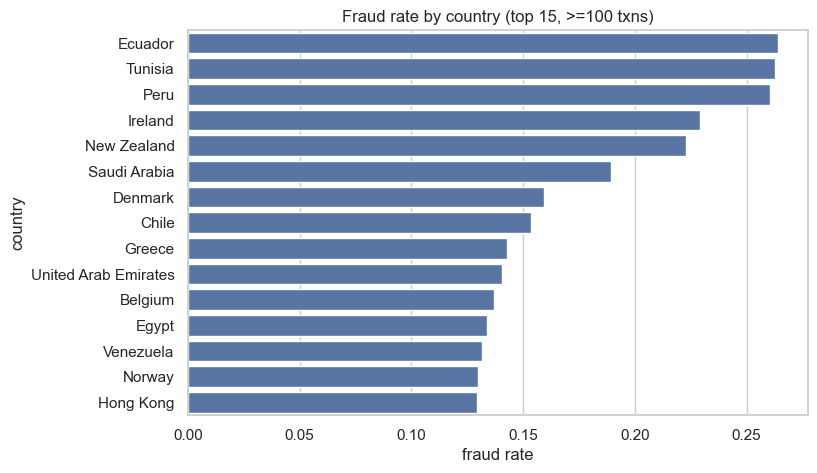

In [4]:
# Fraud patterns by country (top by volume).
if (df['country'] != geo.UNKNOWN_COUNTRY).any():
    rates = geo.fraud_rate_by_country(df, min_count=100)
    print('Highest-fraud-rate countries (>=100 txns):')
    display(rates.head(10))
    top = rates.head(15)
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(y=top.index, x=top['fraud_rate'], ax=ax)
    ax.set(title='Fraud rate by country (top 15, >=100 txns)', xlabel='fraud rate')
    plt.savefig(FIG / 'fraud_rate_by_country.png', dpi=120, bbox_inches='tight')
    plt.show()

## 2. Time features

`hour_of_day`, `day_of_week`, and `time_since_signup` (hours between signup and purchase — near-zero gaps flag automated fraud).

In [5]:
df = fe.add_time_features(df)
display(df[['signup_time','purchase_time','hour_of_day','day_of_week','time_since_signup']].head())
# time_since_signup differs sharply by class:
print(df.groupby('class')['time_since_signup'].median().rename('median_hours'))

,signup_time,purchase_time,hour_of_day,day_of_week,time_since_signup
0,2015-02-24 22:55:49,2015-04-18 02:47:11,2,5,1251.856111
1,2015-06-07 20:39:50,2015-06-08 01:38:54,1,0,4.984444
2,2015-01-01 18:52:44,2015-01-01 18:52:45,18,3,0.000278
3,2015-04-28 21:13:25,2015-05-04 13:54:50,13,0,136.690278
4,2015-07-21 07:09:52,2015-09-09 18:40:53,18,2,1211.516944


class
0    1443.030833
1       0.000278
Name: median_hours, dtype: float64


## 3. Transaction frequency & velocity

Per-user and per-device counts, distinct users per device, and a 24-hour rolling purchase velocity per device.

In [6]:
df = fe.add_frequency_features(df)
df = fe.add_velocity_features(df, window_hours=24.0)
vel_cols = ['user_transaction_count','device_transaction_count',
            'device_user_count','device_velocity_24h']
display(df[vel_cols].describe().round(2))
print('\nMean of each velocity feature by class:')
display(df.groupby('class')[vel_cols].mean().round(2))

,user_transaction_count,device_transaction_count,device_user_count,device_velocity_24h
count,151112.0,151112.00,151112.00,151112.00
mean,1.0,1.68,1.68,1.25
std,0.0,2.62,2.62,1.36
min,1.0,1.00,1.00,1.00
25%,1.0,1.00,1.00,1.00
50%,1.0,1.00,1.00,1.00
75%,1.0,1.00,1.00,1.00
max,1.0,20.00,20.00,19.00



Mean of each velocity feature by class:


,user_transaction_count,device_transaction_count,device_user_count,device_velocity_24h
class,,,,
0,1.0,1.12,1.12,1.00
1,1.0,7.15,7.15,3.68


## 4. Train/test split (before scaling & resampling)

We split **first** so that scaler fitting and SMOTE see only training data — preventing leakage. Stratified to preserve the fraud rate.

In [7]:
from sklearn.model_selection import train_test_split
from src import transform, resampling

numeric_cols = ['purchase_value','age','hour_of_day','day_of_week',
                'time_since_signup','user_transaction_count',
                'device_transaction_count','device_user_count',
                'device_velocity_24h']
categorical_cols = ['source','browser','sex']
feature_cols = numeric_cols + categorical_cols

X = df[feature_cols].copy()
for c in categorical_cols:
    X[c] = X[c].astype(str)
y = df['class']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=config.RANDOM_STATE)
print('Train:', X_train.shape, 'Test:', X_test.shape)

Train: (120889, 12) Test: (30223, 12)


## 5. Scaling + one-hot encoding

`StandardScaler` for numerics, `OneHotEncoder` for categoricals, bundled in a `ColumnTransformer` **fit on the training set only**.

In [8]:
pre = transform.build_preprocessor(numeric_cols, categorical_cols, scaler='standard')
X_train_t = transform.fit_transform_frame(pre, X_train)
X_test_t = transform.transform_frame(pre, X_test)
print('Transformed train matrix:', X_train_t.shape)
X_train_t.head()

Transformed train matrix: (120889, 19)


,num__purchase_value,num__age,num__hour_of_day,num__day_of_week,num__time_since_signup,num__user_transaction_count,num__device_transaction_count,num__device_user_count,num__device_velocity_24h,cat__source_Ads,cat__source_Direct,cat__source_SEO,cat__browser_Chrome,cat__browser_FireFox,cat__browser_IE,cat__browser_Opera,cat__browser_Safari,cat__sex_F,cat__sex_M
50481,0.165515,0.332029,-0.945088,-0.006193,-1.425925,0.0,-0.261965,-0.261965,-0.185381,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
95673,-0.653568,-0.247859,0.647614,-1.002401,1.270903,0.0,-0.261965,-0.261965,-0.185381,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
139063,0.547753,0.911917,-0.365924,-1.002401,0.970864,0.0,-0.261965,-0.261965,-0.185381,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
28313,2.677368,1.027895,1.226779,-0.006193,-0.596899,0.0,-0.261965,-0.261965,-0.185381,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
123477,0.165515,1.027895,0.068450,-1.500505,-1.336306,0.0,-0.261965,-0.261965,-0.185381,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


## 6. Handle class imbalance — SMOTE (training set only)

**Why SMOTE over undersampling?** With ~9% fraud, undersampling the majority would discard the bulk of legitimate transactions and the signal they carry. Random oversampling merely duplicates minority rows (overfitting risk). SMOTE synthesises new minority points by interpolating between near neighbours, enriching the minority region without literal duplicates. **Applied to the training fold only** so the test set keeps the real-world distribution.

In [9]:
X_train_res, y_train_res = resampling.resample(X_train_t, y_train, method='smote')
report = resampling.resample_report(y_train, y_train_res)
print('Class distribution before vs after SMOTE (TRAIN ONLY):')
display(report)
print('Test set distribution is left UNCHANGED:')
display(resampling.class_distribution(y_test))

Class distribution before vs after SMOTE (TRAIN ONLY):


,count_before,pct_before,count_after,pct_after
class,,,,
0,109568,90.635,109568,50.0
1,11321,9.365,109568,50.0


Test set distribution is left UNCHANGED:


,count,pct
class,,
0,27393,90.636
1,2830,9.364


## 7. Persist processed features

In [10]:
# Save the engineered (pre-scaling) frame for reuse + the split sizes.
out_cols = feature_cols + ['country', 'class']
df[out_cols].to_csv(config.FRAUD_FEATURES, index=False)
print('Saved', config.FRAUD_FEATURES)
print('Engineered feature columns:', feature_cols)

Saved /Users/yostinaabera/Documents/fraud-detection/data/processed/fraud_features.csv
Engineered feature columns: ['purchase_value', 'age', 'hour_of_day', 'day_of_week', 'time_since_signup', 'user_transaction_count', 'device_transaction_count', 'device_user_count', 'device_velocity_24h', 'source', 'browser', 'sex']


## 8. Summary

- **Geolocation:** IPs mapped to countries via range lookup; fraud rate varies by country.
- **Engineered features:** `hour_of_day`, `day_of_week`, `time_since_signup`, per-user/device counts, `device_user_count`, `device_velocity_24h`.
- **Transformation:** standardised numerics + one-hot categoricals via a leakage-safe `ColumnTransformer`.
- **Imbalance:** SMOTE balanced the **training** set (~90/10 → 50/50); the **test** set was untouched for honest evaluation.